# Ethnicity QC for Baseline Cross-sectional comparison of HC1|ARI

In [1]:
quiet_library <- function(...){
    suppressPackageStartupMessages(library(...))
}

In [2]:
quiet_library(hise)
quiet_library(purrr)
quiet_library(furrr)
quiet_library(dplyr)
quiet_library(tidyr)
quiet_library(tibble)
quiet_library(stats)
quiet_library(qvalue)
quiet_library(ggplot2)

In [3]:
plan(multisession, workers = 3)

In [4]:
if(!dir.exists("/home/workspace/temp/output")) {
    dir.create("/home/workspace/temp/output")
}

outFiles <- list()

In [5]:
# function to calculate q values on proteins associated with specific covariates

covarQ <- function(df, cov){
    
    a <- df %>%
        filter(variable == paste0(cov))

    b <- qvalue(a$`Pr(>|t|)`)

    c <- a %>%
        mutate(qval = b$qvalues)

}

## Read in baseline ARI olink data

In [6]:
# from IDE for ALTRA Olink Data for Aim 1: CON | ARI (No Subject Metadata) 2024-12-18

a1_uuid <- 'cc6d77a7-7299-42a8-a0dc-b7edaf056c67' # vadof-pofus-pigip/2024-12-18_Olink_altraHCvARI_noMeta.csv

In [7]:
a1_file <- cacheFiles(list(a1_uuid))

a1 <- read.csv(a1_file, 
               header = T, 
               stringsAsFactors = F)

nrow(a1)

[1] "downloading fileID cc6d77a7-7299-42a8-a0dc-b7edaf056c67"


[1] 108283

## Read in Aim 1 HC1|ARI differential proteins

In [8]:
# from IDE for ALTRA Olink Results Aim 1: CON | ARI 2024-10-22

dap_uuid <- '2455b335-7f8f-4839-9145-752cabfe319c' # zahin-totok-popin/2024-10-22_Risk_lm_riskVariable.csv

In [9]:
dap_file <- cacheFiles(list(dap_uuid))

dap <- read.csv(dap_file, 
                header = T, 
                stringsAsFactors = F)

nrow(dap)

[1] "downloading fileID 2455b335-7f8f-4839-9145-752cabfe319c"


[1] 1327

## Read in metadata

In [10]:
meta_uuid <- '32b8bb9c-4834-4e5c-9b3a-7939b3b7f057'

In [11]:
meta_file <- cacheFiles(list(meta_uuid))

meta <- read.csv(meta_file, 
                 header = T, stringsAsFactors = F)

nrow(meta)

[1] "downloading fileID 32b8bb9c-4834-4e5c-9b3a-7939b3b7f057"


[1] 157

In [12]:
conv <- c('CU1003', 'CU1007', 'CU1009', 'CU1010', 'CU1015', 'CU1021', 'CU1029', 
          'CU1033', 'CU1037', 'CU1039', 'CU1044', 'CU1050', 'CU1052', 'CU1053', 
          'SD1003', 'SD1007')

outSubj <- ''

outCols <- c('Status_Long')

In [13]:
meta2 <- meta %>%
    select(-any_of(outCols)) %>%
    filter(!subject.subjectGuid %in% outSubj, 
           Status_Xsec %in% c('ALTRA_healthy', 'at_risk') | 
           Status_Xsec == 'early_RA' & !subject.subjectGuid %in% conv)

In [14]:
table(meta2$Status_Xsec)


ALTRA_healthy       at_risk      early_RA 
           38            45            11 

## Merge olink data and metadata

In [15]:
risk <- a1 %>%
    inner_join(meta2, by = 'sample.sampleKitGuid')

nrow(risk)

[1] 108283

## QC Ethnicity

In [16]:
QC <- risk %>%
    distinct(sample.sampleKitGuid, .keep_all = T)

In [17]:
a <- table(QC$subject.ethnicity, QC$Status)
a

                           
                            ALTRA_healthy at_risk
  Hispanic or Latino origin             9       2
  Non-Hispanic origin                  28      43

In [18]:
fisher.test(a)


	Fisher's Exact Test for Count Data

data:  a
p-value = 0.01913
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
  1.26611 68.91795
sample estimates:
odds ratio 
  6.755786 


Concern over low n in ARI

## Model protein expression including ethnicity | Reference = HC1

In [19]:
# confirm reference point

risk <- risk %>%
    mutate(Status_Xsec = factor(Status_Xsec))

levels(risk$Status_Xsec)

[1] "ALTRA_healthy" "at_risk"

In [20]:
# Split the data by Olink ID
split_data <- split(risk, risk$OlinkID)

In [21]:
# model

modelRisk_refHC1 <- future_map2(
    split_data, names(split_data), 
    function(df1, mk){
    
    fit <- lm(NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + subject.ethnicity,
              data = df1)
    
    fitSummary <- summary(fit)$coef %>%
        as.data.frame() %>% 
        rownames_to_column(var = 'variable') %>%
        filter(!variable == '(Intercept)') %>%
        select(variable, 
               Estimate, 
              `Pr(>|t|)`) %>%
        mutate(OlinkID = mk)
    
    return(fitSummary)
})

paste0('Number of protein assays = ', length(split_data))

[1] "Number of protein assays = 1327"

In [22]:
# all covariate data

fitDF_refHC1 <- bind_rows(modelRisk_refHC1) %>%
    as.data.frame() %>%
    mutate(Assay = risk$Assay[match(OlinkID, table = risk$OlinkID)],
           Assay_OID = risk$Assay_OID[match(OlinkID, table = risk$OlinkID)],
           UniProt = risk$UniProt[match(OlinkID, table = risk$OlinkID)],
           UniProt_OID = risk$UniProt_OID[match(OlinkID, table = risk$OlinkID)]) %>% 
    arrange(`Pr(>|t|)`)


cat('Output: All Variables')
cat('\n\n')
head(fitDF_refHC1)
nrow(fitDF_refHC1)
table(fitDF_refHC1$variable)

Output: All Variables



,variable,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ageAtDraw,0.03229048,7.487326e-18,OID21451,EDA2R,EDA2R_OID21451,Q9HAV5,Q9HAV5_OID21451
2,ageAtDraw,0.02802149,1.821901e-15,OID20254,LTBP2,LTBP2_OID20254,Q14767,Q14767_OID20254
3,ageAtDraw,0.02987694,9.065788e-14,OID20251,GDF15,GDF15_OID20251,Q99988,Q99988_OID20251
4,ageAtDraw,0.03263356,1.076561e-13,OID20622,CXCL17,CXCL17_OID20622,Q6UXB2,Q6UXB2_OID20622
5,ageAtDraw,0.02151807,3.259031e-12,OID20460,WNT9A,WNT9A_OID20460,O14904,O14904_OID20460
6,ageAtDraw,0.02680433,1.458828e-11,OID21063,MSR1,MSR1_OID21063,P21757,P21757_OID21063


[1] 5308


                  Status_Xsecat_risk                            ageAtDraw 
                                1327                                 1327 
           subject.biologicalSexMale subject.ethnicityNon-Hispanic origin 
                                1327                                 1327 

In [23]:
# Risk variable

riskARI <- covarQ(fitDF_refHC1, 'Status_Xsecat_risk') %>%
    mutate(Reference = 'HC1', .after = variable)

head(riskARI)
nrow(riskARI)

,variable,Reference,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID,qval
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,Status_Xsecat_risk,HC1,1.0852641,2.922279e-11,OID20427,IL1B,IL1B_OID20427,P01584,P01584_OID20427,2.043570e-08
2,Status_Xsecat_risk,HC1,0.6261128,2.074638e-08,OID20569,CCL28,CCL28_OID20569,Q9NRJ3,Q9NRJ3_OID20569,6.404136e-06
3,Status_Xsecat_risk,HC1,1.4620374,2.747350e-08,OID20068,TIA1,TIA1_OID20068,P31483,P31483_OID20068,6.404136e-06
4,Status_Xsecat_risk,HC1,1.0686770,4.220011e-08,OID20542,SCRN1,SCRN1_OID20542,Q12765,Q12765_OID20542,7.377706e-06
5,Status_Xsecat_risk,HC1,1.7746148,1.238076e-07,OID20425,RAB37,RAB37_OID20425,Q96AX2,Q96AX2_OID20425,1.731591e-05
6,Status_Xsecat_risk,HC1,0.7607287,1.615582e-07,OID20520,HLA-DRA,HLA-DRA_OID20520,P01903,P01903_OID20520,1.882979e-05


[1] 1327

In [24]:
out_Ethnicity <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_Ethnicity_Model_riskVariable.csv"
)

write.csv(
    riskARI, 
    out_Ethnicity,
    row.names = TRUE
)

outFiles <- c(outFiles, out_Ethnicity)

## Visualization: Correlation between Original and Ethnicity models

In [25]:
# function to join dataframes for correlation plots

joinDF <- function(df1, suf1, df2, suf2){

    in1 <- df1 %>%
        select(OlinkID, 
               Assay_OID, 
               Estimate, 
               qval)

    in2 <- df2 %>%
        select(OlinkID, 
               Assay_OID, 
               Estimate,
               qval)

    out <- in1 %>%
        left_join(in2, by = c('OlinkID', 'Assay_OID'), 
                  suffix = c(paste(suf1), paste(suf2)))

}

In [26]:
ethn_corr <- joinDF(riskARI, '_new', dap, '_original')

head(ethn_corr)
nrow(ethn_corr)

,OlinkID,Assay_OID,Estimate_new,qval_new,Estimate_original,qval_original
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,OID20427,IL1B_OID20427,1.0852641,2.043570e-08,1.0890537,2.144259e-09
2,OID20569,CCL28_OID20569,0.6261128,6.404136e-06,0.6189482,2.776694e-06
3,OID20068,TIA1_OID20068,1.4620374,6.404136e-06,1.2796166,5.395956e-05
4,OID20542,SCRN1_OID20542,1.0686770,7.377706e-06,1.0241385,8.039096e-06
5,OID20425,RAB37_OID20425,1.7746148,1.731591e-05,1.5279365,2.276932e-04
6,OID20520,HLA-DRA_OID20520,0.7607287,1.882979e-05,0.7649266,8.039096e-06


[1] 1327

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'


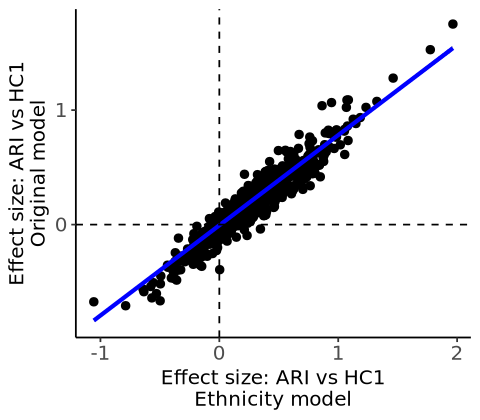

In [27]:
options(repr.plot.width = 4, repr.plot.height = 3.5)

p <- ggplot(ethn_corr, aes(x=Estimate_new, 
                      y=Estimate_original)) + 
    geom_point(size = 2) + 
    geom_smooth(method = 'lm', 
                colour = 'blue', 
                fill = 'grey50',
                size = 1.2) + 
    geom_hline(yintercept = 0, 
               linetype = 'dashed') +
    geom_vline(xintercept = 0, 
               linetype = 'dashed') + 
    scale_colour_manual(values = c('black')) + 
    labs(x='Effect size: ARI vs HC1\nEthnicity model', 
         y='Effect size: ARI vs HC1\nOriginal model') + 
    theme_classic() + 
    theme (plot.title = element_text(size=12, face='bold', hjust=0.5), 
           legend.position = 'none',
           #legend.text = element_text(size = 12),
           #legend.title = element_text(size=12),
           axis.text.y = element_text(size = 12),
           axis.text.x = element_text(size = 12), 
           axis.title.y = element_text(size = 12), 
           axis.title.x = element_text(size = 12))

print(p)

In [28]:
ggsave(filename = 'Ethnicity_correlation.pdf', 
       path = 'Figures',
       create.dir = T,
       p,
       device = 'pdf', 
       width = 4, 
       height = 3.5, 
       units = 'in')

`geom_smooth()` using formula = 'y ~ x'


In [29]:
cor.test(x = ethn_corr$Estimate_new, 
         y = ethn_corr$Estimate_original, 
         method = 'spearman')


	Spearman's rank correlation rho

data:  ethn_corr$Estimate_new and ethn_corr$Estimate_original
S = 20173512, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.9482011 


## Store results in HISE

In [30]:
study_space_uuid <- '223de760-9624-45bd-aefe-ca24c75b1800'

title <- paste('ALTRA Olink Ethnicity Modeling: HC1 | ARI', Sys.Date())

In [31]:
search_id <- ids::proquint(n_words = 3)
search_id

[1] "ligom-hozut-mapuh"

In [32]:
in_list <- list(a1_uuid, dap_uuid, meta_uuid)

In [33]:
outFiles

[[1]]
[1] "/home/workspace/temp/output/2025-03-20_Ethnicity_Model_riskVariable.csv"

In [34]:
uploadFiles(
    files = outFiles,
    studySpaceId = study_space_uuid,
    title = title,
    inputFileIds = in_list,
    destination = search_id,
    store = "project",
    doPrompt = FALSE
)

$Message
[1] "General Okay-ness"

$VisualizationId
[1] "00000000-0000-0000-0000-000000000000"

$AbstractionId
[1] "00000000-0000-0000-0000-000000000000"

$TraceId
[1] "e3edab74-4334-4573-9c5f-01cf71f2325c"

$ProcessId
[1] "4e2f212f-033b-4c49-9b74-ec8a9bdc05d6"

$WorkflowId
[1] "62b94d31-df15-42ba-8a5b-c69b8c5356ef"

$FileIds
$FileIds[[1]]
[1] "774988a0-944d-42c0-a614-bd0aefeb18ec"

In [35]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ggplot2_3.5.1 qvalue_2.34.0 tibble_3.2.1  tidyr_1.3.1   dplyr_1.1.4  
[6] furrr_0.3.1   future_1.34.0 purrr_1.0.2   hise_2.16.0  

loaded via a namespace (and not attached):
 [1] utf8_1.2.4        generics_0.1.3    bitops_1.0-8      lattice_0.22-6   
 [5] stringi_1.8.4     listenv_0.9.1     digest_0.6.36     